<h1 id="Lecture-7:-Machine-Learning-Fundamentals-and-Evaluation">Lecture 7: Machine Learning Fundamentals and Evaluation</h1><p>A learner estimates a function from examples. The aim is not to minimize a number on the table we already have. The aim is to make useful predictions for relevant, unseen cases.</p>
<p><strong>Running question:</strong> Can a service team predict delivery time early enough to make a useful intervention? We will define the unit, information set, target, loss, split, and decision rule before comparing models.</p>

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay, mean_absolute_error, mean_squared_error, brier_score_loss
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

from ds301.paths import project_root
ROOT = project_root()
DATA = ROOT / "data"
TEAL, MINT, GOLD, CORAL, INK = "#005F73", "#0A9396", "#EE9B00", "#BB3E03", "#1D3557"
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.titleweight": "bold", "axes.labelsize": 11})
rng = np.random.default_rng(301)

<h2 id="Begin-with-the-records-and-the-decision-moment">Begin with the records and the decision moment</h2><p>A learning visual should always trace back to cases and fields. Here one row is one completed delivery. The outcome is delivery minutes; distance, item count, and rain are available at acceptance. We will first inspect these records, then define errors, loss, and a fitted function.</p>

In [2]:
delivery_records = pd.read_csv(DATA / "delivery_regression.csv")
delivery_records[["distance_km", "items", "rain_mm", "delivery_minutes"]].head(10)

,distance_km,items,rain_mm,delivery_minutes
0,1.37,1,1.45,20.6
1,9.01,5,0.07,38.9
2,10.28,6,2.20,39.0
3,11.50,6,0.13,45.8
4,9.47,5,9.66,47.3
5,2.56,1,0.10,27.3
6,13.12,1,4.42,54.1
7,5.05,1,4.79,33.3
8,5.21,7,1.04,29.1
9,12.66,6,0.77,50.4


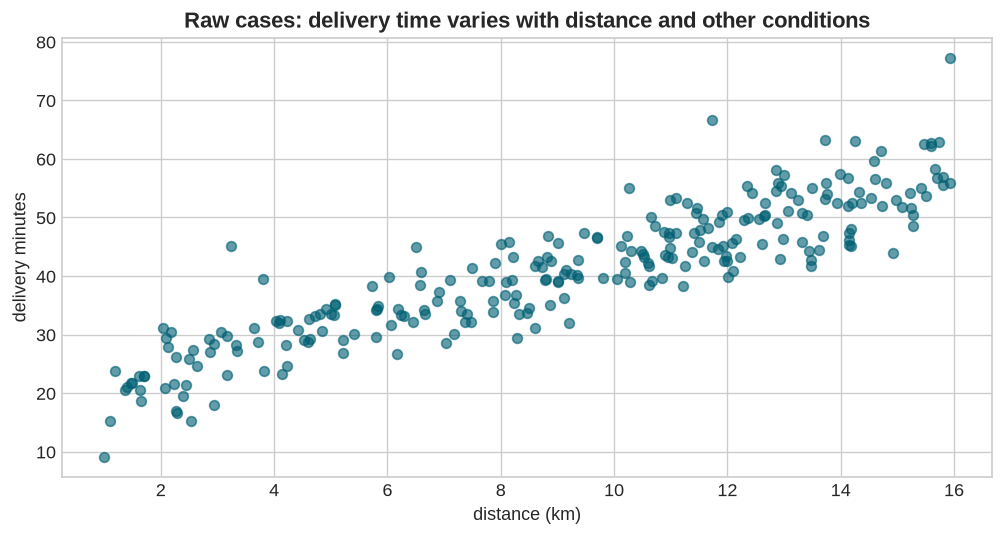

In [3]:
fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.scatter(delivery_records.distance_km, delivery_records.delivery_minutes, c=TEAL, alpha=.62, s=34)
ax.set(title="Raw cases: delivery time varies with distance and other conditions", xlabel="distance (km)", ylabel="delivery minutes")
plt.tight_layout()

<h2 id="1.-The-learning-contract">1. The learning contract</h2><p>A supervised learning problem needs an unambiguous contract.</p>
<table>
<thead>
<tr>
<th>Element</th>
<th>Delivery-time example</th>
</tr>
</thead>
<tbody>
<tr>
<td>Unit</td>
<td>one accepted delivery</td>
</tr>
<tr>
<td>Features (X)</td>
<td>distance, number of items, rain observed at acceptance</td>
</tr>
<tr>
<td>Target (y)</td>
<td>delivery minutes</td>
</tr>
<tr>
<td>Prediction time</td>
<td>immediately after acceptance</td>
</tr>
<tr>
<td>Loss</td>
<td>mean squared error during fitting</td>
</tr>
<tr>
<td>Operational metric</td>
<td>MAE in minutes, plus a late-delivery guardrail</td>
</tr>
</tbody>
</table>
<p>A target recorded after acceptance may be useful for evaluation, but it is forbidden as an input at prediction time.</p>

<h2 id="2.-Learning-settings-and-task-types">2. Learning settings and task types</h2><p>The same data table can support different learning settings. The setting follows the question, not the software menu.</p>

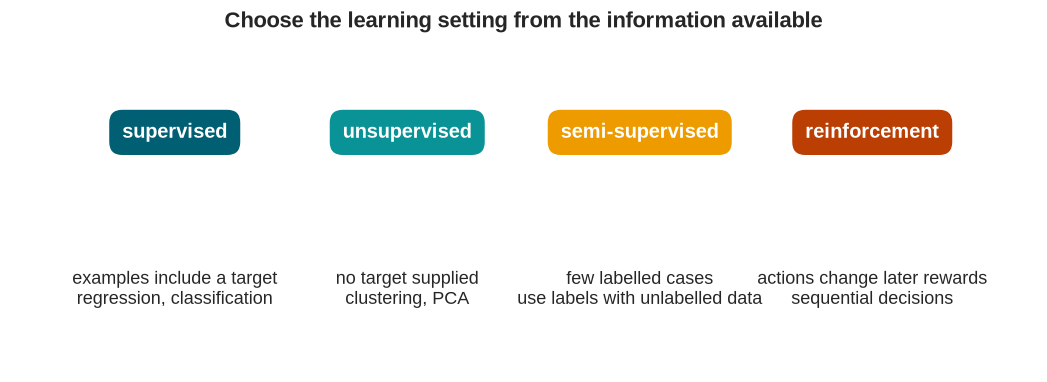

In [4]:
fig, ax = plt.subplots(figsize=(11, 3.6))
settings = [
    ("supervised", "examples include a target", "regression, classification"),
    ("unsupervised", "no target supplied", "clustering, PCA"),
    ("semi-supervised", "few labelled cases", "use labels with unlabelled data"),
    ("reinforcement", "actions change later rewards", "sequential decisions"),
]
for i, (name, evidence, use) in enumerate(settings):
    ax.text(i, 1.0, name, ha="center", va="center", color="white", weight="bold", fontsize=12,
            bbox=dict(boxstyle="round,pad=.65", fc=[TEAL, MINT, GOLD, CORAL][i], ec="none"))
    ax.text(i, .34, evidence + "\n" + use, ha="center", va="center")
ax.set(xlim=(-.7, 3.7), ylim=(0, 1.4), title="Choose the learning setting from the information available"); ax.axis("off")
plt.show()

<h2 id="3.-Loss,-metric,-and-surrogate-loss">3. Loss, metric, and surrogate loss</h2><p>A <strong>loss</strong> penalizes one prediction during fitting. A <strong>metric</strong> summarizes performance for an audience or decision. A <strong>surrogate loss</strong> makes a difficult goal easier to optimize.</p>

In [5]:
error_examples = pd.DataFrame({"actual minutes": [20, 20, 20, 20], "predicted minutes": [19, 23, 15, 32]})
error_examples["error"] = error_examples["predicted minutes"] - error_examples["actual minutes"]
error_examples["absolute error"] = error_examples.error.abs()
error_examples["squared error"] = error_examples.error**2
error_examples

,actual minutes,predicted minutes,error,absolute error,squared error
0,20,19,-1,1,1
1,20,23,3,3,9
2,20,15,-5,5,25
3,20,32,12,12,144


<p>The table makes the choice visible: moving from a 5-minute error to a 12-minute error adds 7 minutes under MAE but adds much more penalty under MSE. The curve now generalises that calculation to every possible error.</p>

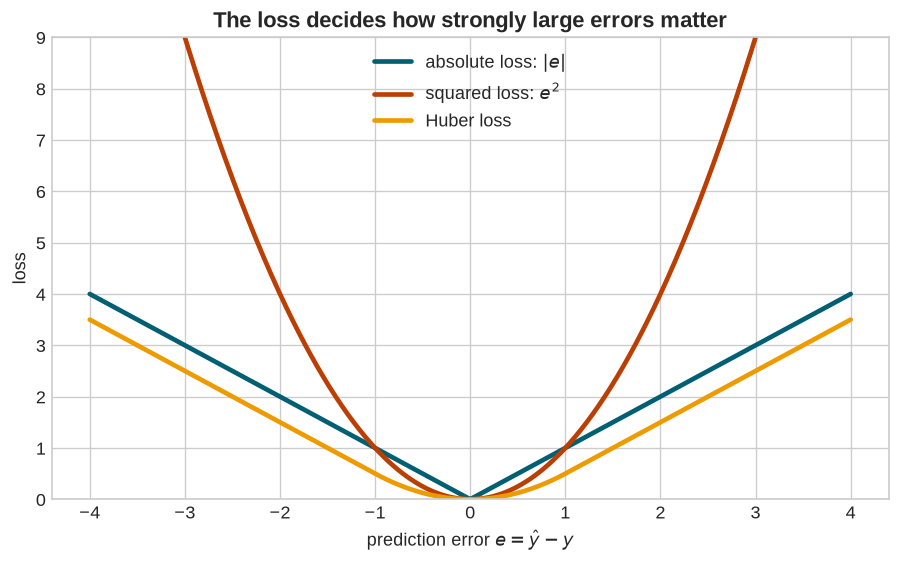

In [6]:
errors = np.linspace(-4, 4, 500)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(errors, np.abs(errors), lw=2.8, c=TEAL, label="absolute loss: $|e|$")
ax.plot(errors, errors**2, lw=2.8, c=CORAL, label="squared loss: $e^2$")
ax.plot(errors, np.where(np.abs(errors) <= 1, .5 * errors**2, np.abs(errors) - .5), lw=2.8, c=GOLD, label="Huber loss")
ax.set(ylim=(0, 9), xlabel="prediction error $e = \\hat y-y$", ylabel="loss", title="The loss decides how strongly large errors matter")
ax.legend()
plt.show()

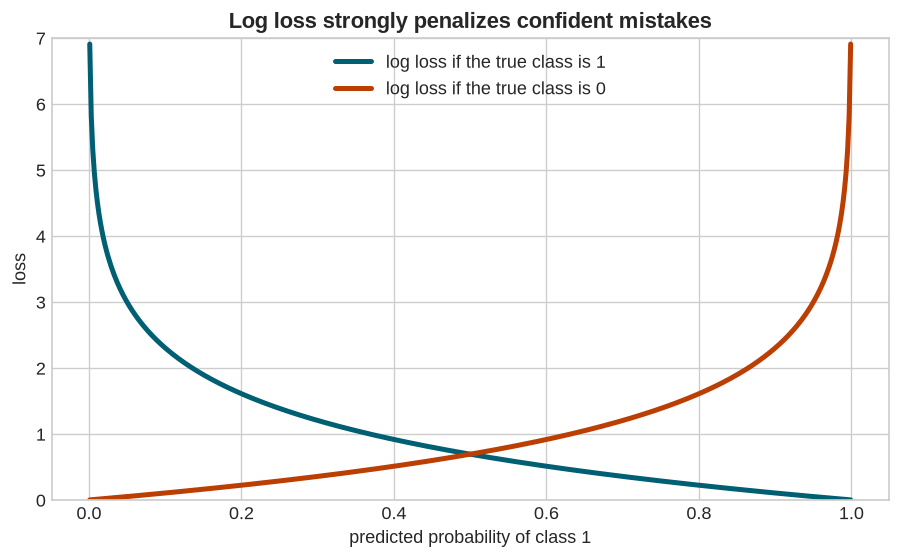

In [7]:
prob = np.linspace(.001, .999, 500)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(prob, -np.log(prob), c=TEAL, lw=3, label="log loss if the true class is 1")
ax.plot(prob, -np.log(1 - prob), c=CORAL, lw=3, label="log loss if the true class is 0")
ax.set(ylim=(0, 7), xlabel="predicted probability of class 1", ylabel="loss", title="Log loss strongly penalizes confident mistakes")
ax.legend()
plt.show()

<h2 id="4.-Empirical-risk-minimization">4. Empirical risk minimization</h2><p>We cannot observe population risk $R(f)=E[L(Y,f(X))]$. We minimize empirical risk, the average loss on a sample, often with a complexity penalty:</p>
<p>$$\hat f=\arg\min_f \frac{1}{n}\sum_{i=1}^nL(y_i,f(x_i))+\lambda\Omega(f).$$</p>

In [8]:
x = np.linspace(-1.2, 2.4, 42)
y = 2.0 + 1.35 * x + rng.normal(0, .55, len(x))
candidate = 1.8 + 1.1 * x
losses = pd.DataFrame({"actual": y, "prediction": candidate, "squared error": (y-candidate)**2, "absolute error": abs(y-candidate)})
losses.head(), losses[["squared error", "absolute error"]].mean().rename("empirical risk")

(     actual  prediction  squared error  absolute error
 0  0.600302    0.480000       0.014473        0.120302
 1 -0.389405    0.576585       0.933138        0.965990
 2 -0.393239    0.673171       1.137229        1.066410
 3  0.170448    0.769756       0.359170        0.599308
 4  0.813050    0.866341       0.002840        0.053291,
 squared error     0.535697
 absolute error    0.599936
 Name: empirical risk, dtype: float64)

<h2 id="5.-Loss-surface-and-gradient-descent">5. Loss surface and gradient descent</h2><p>For a simple line $\hat y=\beta_0+\beta_1x$, each point in the contour plane represents a parameter pair, and each contour joins pairs with equal loss. Gradient descent moves in the direction of decreasing local loss.</p>

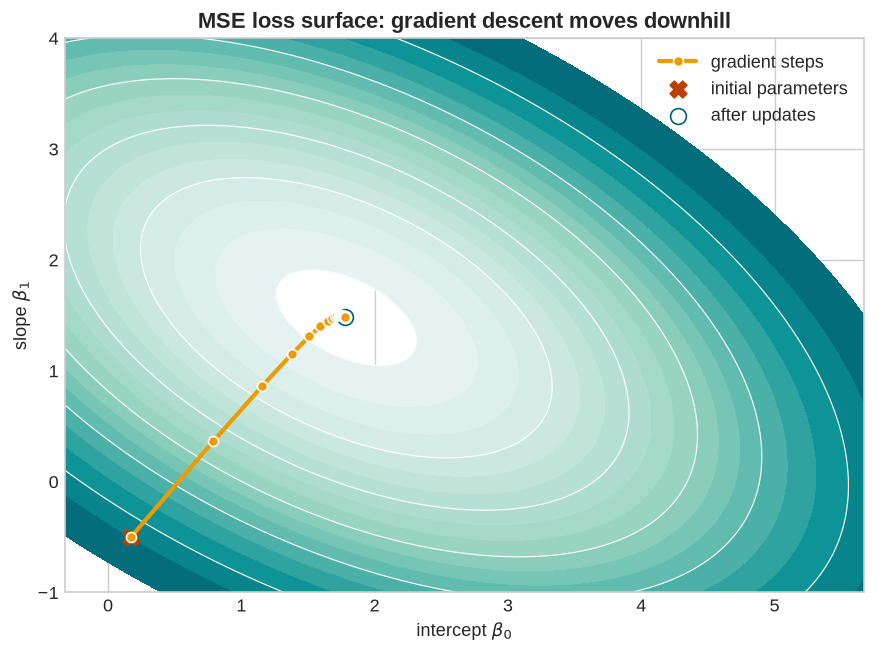

In [9]:
def mse_surface(x, y, learning_rate=.11, steps=20):
    intercepts = np.linspace(y.mean() - 3, y.mean() + 3, 130)
    slopes = np.linspace(-1, 4, 130)
    B0, B1 = np.meshgrid(intercepts, slopes)
    loss = ((y[:, None, None] - (B0[None] + B1[None] * x[:, None, None])) ** 2).mean(axis=0)
    b0, b1 = y.mean() - 2.5, -.5
    path = [(b0, b1)]
    for _ in range(steps):
        residual = b0 + b1*x - y
        b0 -= learning_rate * 2 * residual.mean()
        b1 -= learning_rate * 2 * (residual*x).mean()
        path.append((b0, b1))
    return B0, B1, loss, np.asarray(path)

B0, B1, surface, path = mse_surface(x, y)
fig, ax = plt.subplots(figsize=(8.6, 6))
cmap = LinearSegmentedColormap.from_list("course", ["#EAF4F4", "#94D2BD", MINT, TEAL])
levels = np.quantile(surface, np.linspace(.02, .9, 18))
ax.contourf(B0, B1, surface, levels=levels, cmap=cmap)
ax.contour(B0, B1, surface, levels=levels[::3], colors="white", linewidths=.7)
ax.plot(path[:, 0], path[:, 1], "o-", c=GOLD, lw=2.5, markeredgecolor="white", label="gradient steps")
ax.scatter(*path[0], marker="X", c=CORAL, s=100, label="initial parameters")
ax.scatter(*path[-1], c="white", edgecolor=TEAL, s=90, label="after updates")
ax.set(xlabel="intercept $\\beta_0$", ylabel="slope $\\beta_1$", title="MSE loss surface: gradient descent moves downhill")
ax.legend()
plt.show()

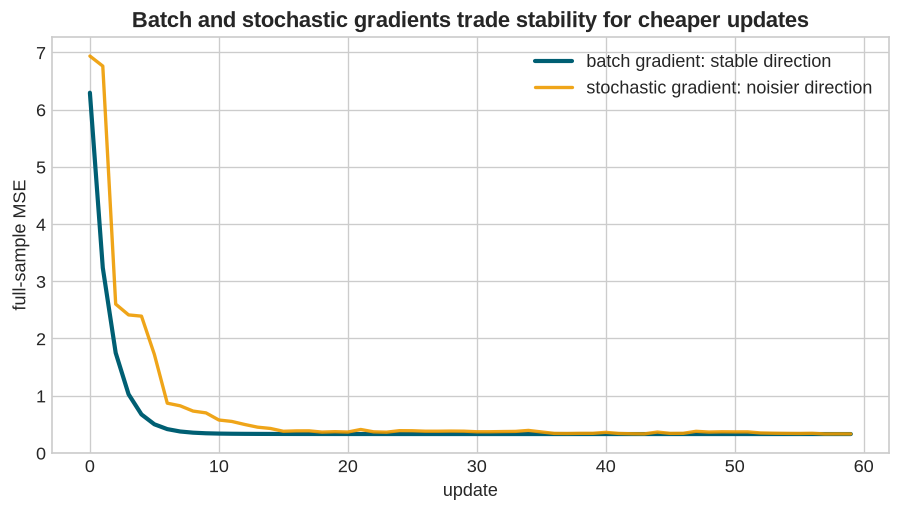

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))
batch_history, stochastic_history = [], []
b0, b1 = path[0]
for _ in range(60):
    residual = b0 + b1*x - y
    b0 -= .08 * 2 * residual.mean(); b1 -= .08 * 2 * (residual*x).mean()
    batch_history.append(np.mean((b0+b1*x-y)**2))
b0, b1 = path[0]
for _ in range(60):
    i = rng.integers(len(x)); residual = b0+b1*x[i]-y[i]
    b0 -= .03 * 2 * residual; b1 -= .03 * 2 * residual*x[i]
    stochastic_history.append(np.mean((b0+b1*x-y)**2))
ax.plot(batch_history, c=TEAL, lw=2.5, label="batch gradient: stable direction")
ax.plot(stochastic_history, c=GOLD, lw=2, alpha=.9, label="stochastic gradient: noisier direction")
ax.set(xlabel="update", ylabel="full-sample MSE", title="Batch and stochastic gradients trade stability for cheaper updates")
ax.legend()
plt.show()

<h2 id="6.-Underfitting,-overfitting,-and-learning-curves">6. Underfitting, overfitting, and learning curves</h2>

## Training and validation loss during optimisation

The training loss is calculated on examples used to update parameters. Validation loss is calculated on held-out examples and is **never** used to update them. It tells us when additional optimisation starts fitting details of the training sample rather than the underlying relationship.

First inspect the observations and split them into fitting and validation sets. We then fit a deliberately flexible polynomial model by gradient descent. The stopping point is the epoch with the lowest validation loss, not necessarily the final epoch or the epoch with the lowest training loss.


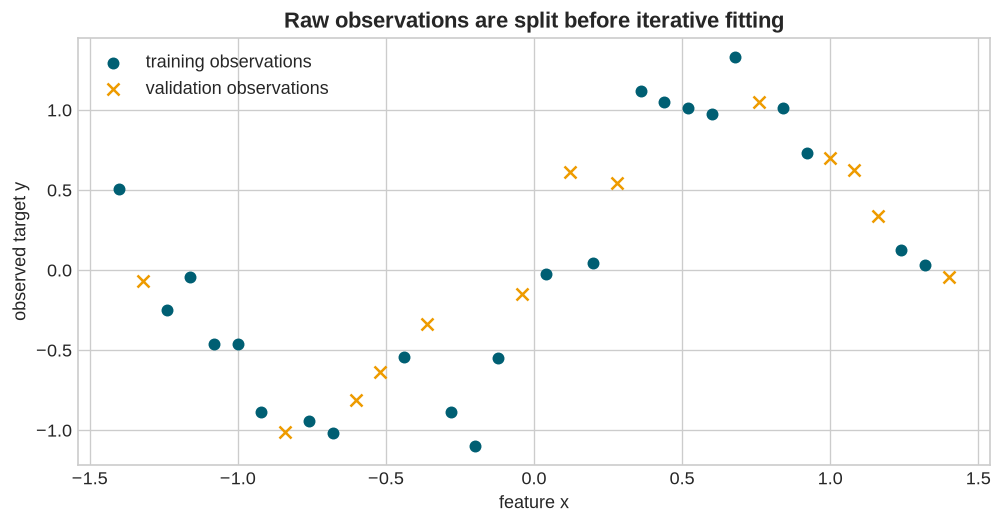

Lowest validation MSE: epoch 1,169; training MSE = 0.551; validation MSE = 0.346


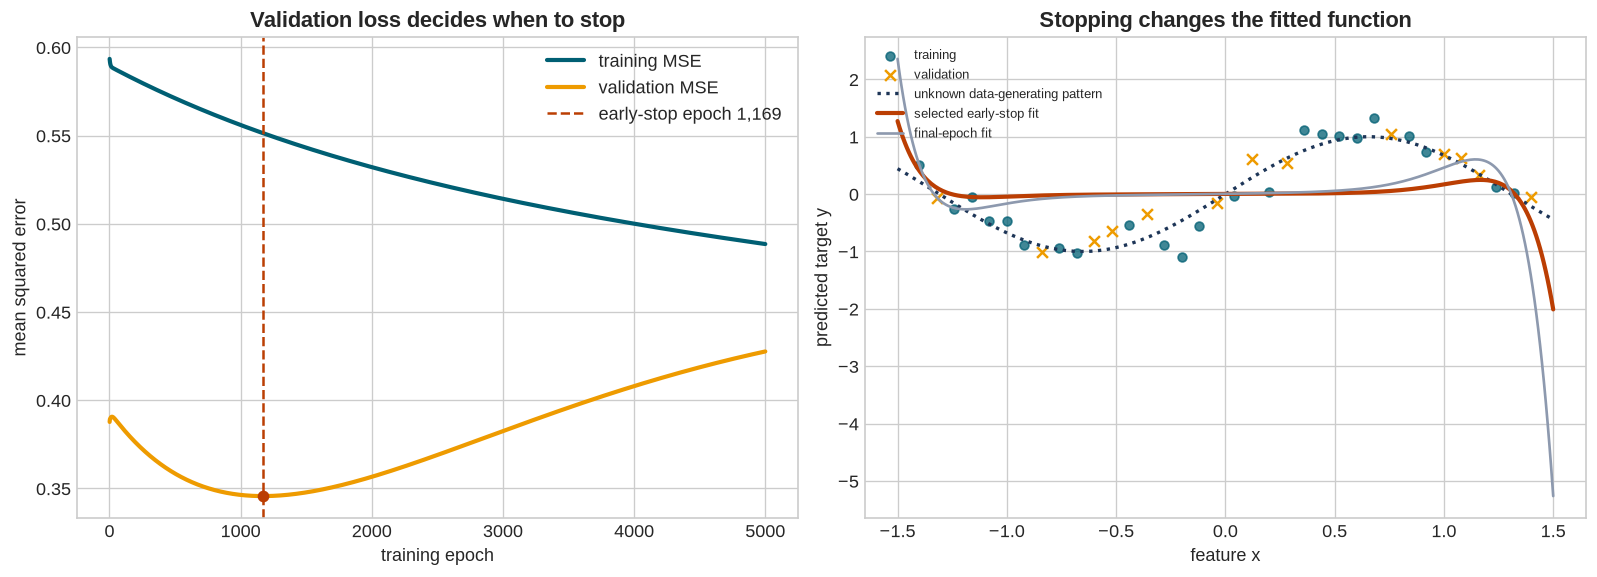

In [11]:
# Controlled nonlinear data: raw observations before fitting.
# A degree-12 polynomial is deliberately flexible enough to overfit this small sample.
epoch_rng = np.random.default_rng(7301)
epoch_x = np.linspace(-1.4, 1.4, 36)
epoch_y = np.sin(2.4 * epoch_x) + epoch_rng.normal(0, .20, len(epoch_x))
epoch_train_x, epoch_val_x, epoch_train_y, epoch_val_y = train_test_split(
    epoch_x, epoch_y, test_size=.35, random_state=301
)
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.scatter(epoch_train_x, epoch_train_y, color=TEAL, s=38, label='training observations')
ax.scatter(epoch_val_x, epoch_val_y, color=GOLD, marker='x', s=52, label='validation observations')
ax.set(xlabel='feature x', ylabel='observed target y',
       title='Raw observations are split before iterative fitting')
ax.legend(); plt.tight_layout(); plt.show()

# Build the polynomial design matrix using the training scale only. Keeping the
# validation examples outside every update preserves their role as a check.
def polynomial_design(x_values, degree, center, scale):
    z = (np.asarray(x_values) - center) / scale
    return np.column_stack([z**power for power in range(degree + 1)])

degree = 12
train_center, train_scale = epoch_train_x.mean(), epoch_train_x.std()
epoch_X_train = polynomial_design(epoch_train_x, degree, train_center, train_scale)
epoch_X_val = polynomial_design(epoch_val_x, degree, train_center, train_scale)
theta_epoch = np.zeros(degree + 1)
learning_rate, epochs = 1e-5, 5_000
train_loss_by_epoch, validation_loss_by_epoch, theta_history = [], [], []
for epoch in range(epochs):
    train_residual = epoch_X_train @ theta_epoch - epoch_train_y
    gradient = 2 * epoch_X_train.T @ train_residual / len(epoch_train_y)
    theta_epoch -= learning_rate * gradient
    train_loss_by_epoch.append(np.mean((epoch_X_train @ theta_epoch - epoch_train_y)**2))
    validation_loss_by_epoch.append(np.mean((epoch_X_val @ theta_epoch - epoch_val_y)**2))
    theta_history.append(theta_epoch.copy())

best_epoch = int(np.argmin(validation_loss_by_epoch))
best_theta, final_theta = theta_history[best_epoch], theta_history[-1]
print(f'Lowest validation MSE: epoch {best_epoch + 1:,}; '
      f'training MSE = {train_loss_by_epoch[best_epoch]:.3f}; '
      f'validation MSE = {validation_loss_by_epoch[best_epoch]:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.7), layout='constrained')
epoch_number = np.arange(1, epochs + 1)
axes[0].plot(epoch_number, train_loss_by_epoch, color=TEAL, lw=2.5, label='training MSE')
axes[0].plot(epoch_number, validation_loss_by_epoch, color=GOLD, lw=2.5, label='validation MSE')
axes[0].axvline(best_epoch + 1, color=CORAL, ls='--', label=f'early-stop epoch {best_epoch + 1:,}')
axes[0].scatter([best_epoch + 1], [validation_loss_by_epoch[best_epoch]], color=CORAL, zorder=3)
axes[0].set(xlabel='training epoch', ylabel='mean squared error', title='Validation loss decides when to stop')
axes[0].legend()

epoch_grid = np.linspace(-1.5, 1.5, 350)
grid_design = polynomial_design(epoch_grid, degree, train_center, train_scale)
axes[1].scatter(epoch_train_x, epoch_train_y, color=TEAL, s=28, alpha=.75, label='training')
axes[1].scatter(epoch_val_x, epoch_val_y, color=GOLD, marker='x', s=42, label='validation')
axes[1].plot(epoch_grid, np.sin(2.4 * epoch_grid), color=INK, lw=2, ls=':', label='unknown data-generating pattern')
axes[1].plot(epoch_grid, grid_design @ best_theta, color=CORAL, lw=2.5, label='selected early-stop fit')
axes[1].plot(epoch_grid, grid_design @ final_theta, color='#8D99AE', lw=1.6, label='final-epoch fit')
axes[1].set(xlabel='feature x', ylabel='predicted target y', title='Stopping changes the fitted function')
axes[1].legend(fontsize=8, loc='upper left')
plt.show()


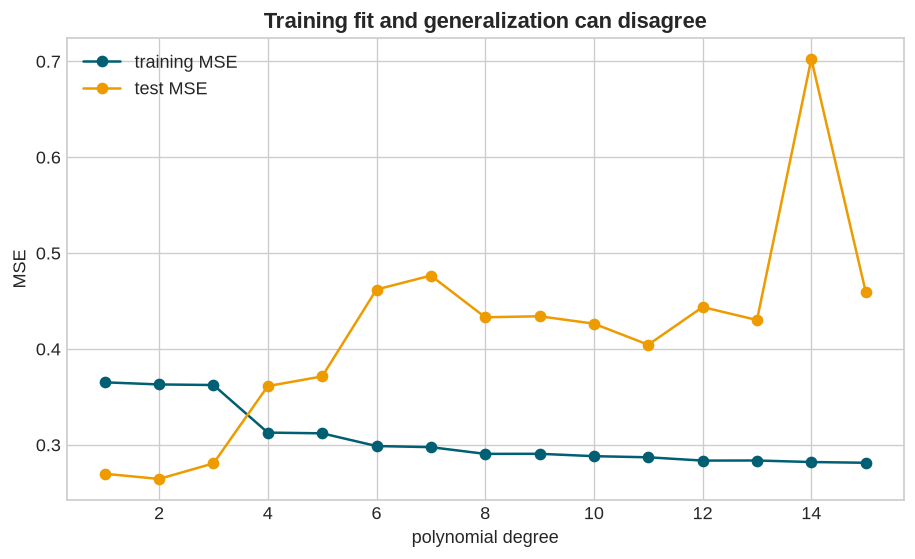

In [12]:
X_train, X_test, y_train, y_test = train_test_split(x[:, None], y, test_size=.30, random_state=301)
degrees = range(1, 16)
train_mse, test_mse = [], []
for degree in degrees:
    model = make_pipeline(PolynomialFeatures(degree), Ridge(alpha=.03)).fit(X_train, y_train)
    train_mse.append(mean_squared_error(y_train, model.predict(X_train)))
    test_mse.append(mean_squared_error(y_test, model.predict(X_test)))
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(degrees, train_mse, "o-", c=TEAL, label="training MSE")
ax.plot(degrees, test_mse, "o-", c=GOLD, label="test MSE")
ax.set(xlabel="polynomial degree", ylabel="MSE", title="Training fit and generalization can disagree")
ax.legend()
plt.show()

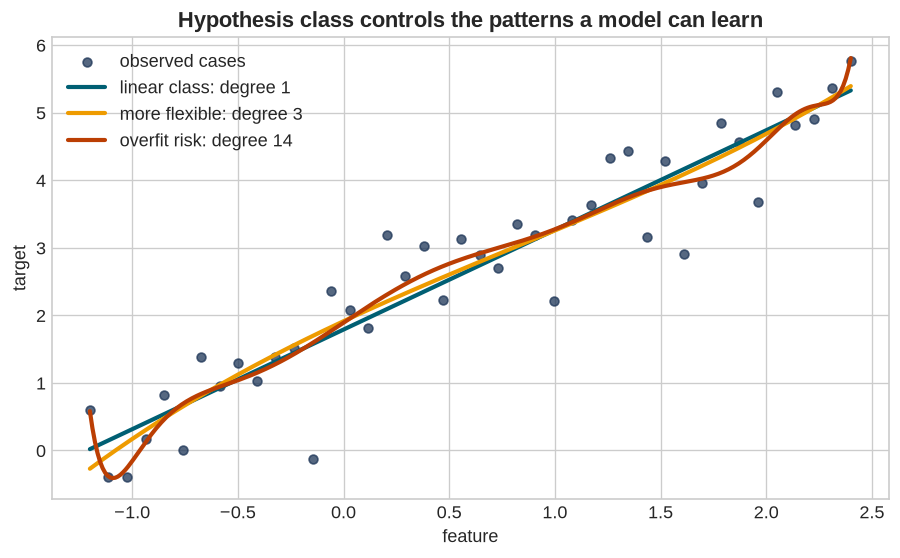

In [13]:
models = [("linear class: degree 1", 1, TEAL), ("more flexible: degree 3", 3, GOLD), ("overfit risk: degree 14", 14, CORAL)]
grid = np.linspace(x.min(), x.max(), 300)
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(x, y, c=INK, s=28, alpha=.75, label="observed cases")
for label, degree, colour in models:
    model = make_pipeline(PolynomialFeatures(degree), Ridge(alpha=.03)).fit(x[:, None], y)
    ax.plot(grid, model.predict(grid[:, None]), lw=2.5, c=colour, label=label)
ax.set(xlabel="feature", ylabel="target", title="Hypothesis class controls the patterns a model can learn")
ax.legend()
plt.show()

<h2 id="7.-Regularization-and-leakage">7. Regularization and leakage</h2>

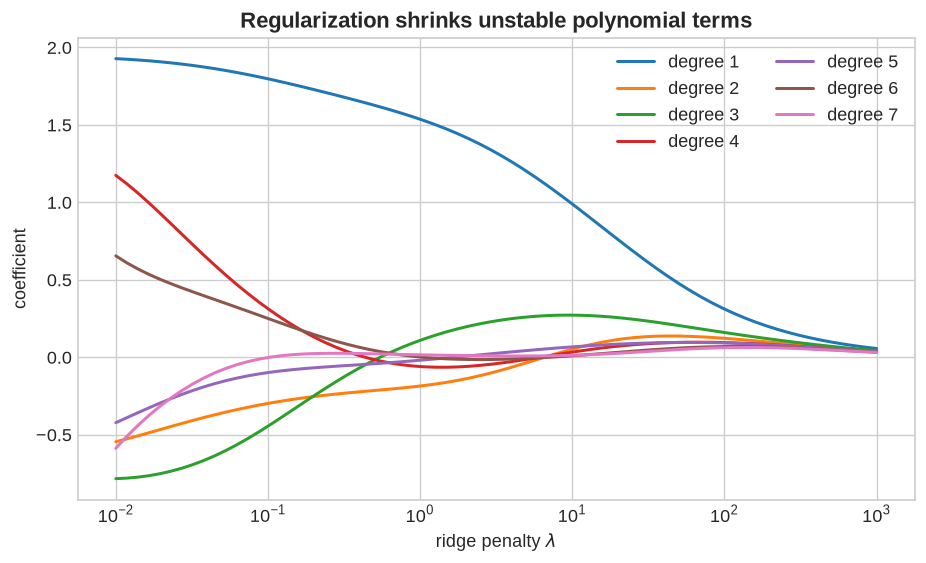

In [14]:
# Polynomial terms can have very different scales. Standardising them makes one
# ridge penalty comparable across terms and keeps the numerical demonstration stable.
X_poly_raw = PolynomialFeatures(10, include_bias=False).fit_transform(x[:, None])
X_poly = StandardScaler().fit_transform(X_poly_raw)
alphas = np.logspace(-2, 3, 70)
paths = np.array([Ridge(alpha=a, solver="svd").fit(X_poly, y).coef_ for a in alphas])
fig, ax = plt.subplots(figsize=(9, 5))
for i in range(min(7, paths.shape[1])):
    ax.semilogx(alphas, paths[:, i], lw=1.8, label=f"degree {i+1}")
ax.set(xlabel="ridge penalty $\\lambda$", ylabel="coefficient", title="Regularization shrinks unstable polynomial terms")
ax.legend(ncol=2)
plt.show()

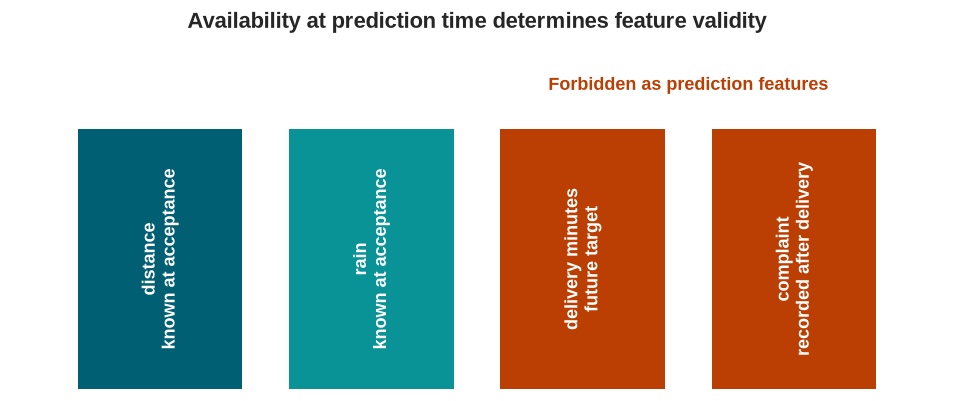

In [15]:
fig, ax = plt.subplots(figsize=(10, 3.8))
columns = [("distance\nknown at acceptance", TEAL), ("rain\nknown at acceptance", MINT), ("delivery minutes\nfuture target", CORAL), ("complaint\nrecorded after delivery", CORAL)]
for i, (label, colour) in enumerate(columns):
    ax.bar(i, 1, color=colour, width=.78); ax.text(i, .5, label, rotation=90, ha="center", va="center", color="white", weight="bold")
ax.text(2.5, 1.15, "Forbidden as prediction features", ha="center", c=CORAL, weight="bold")
ax.set(ylim=(0, 1.35), xlim=(-.7, 3.7), title="Availability at prediction time determines feature validity"); ax.axis("off")
plt.show()

<h2 id="8.-Splits,-cross-validation,-and-regression-metrics">8. Splits, cross-validation, and regression metrics</h2>

5-fold mean-baseline MAE    9.28
5-fold MAE                  2.96
fold-to-fold SD             0.27
dtype: float64


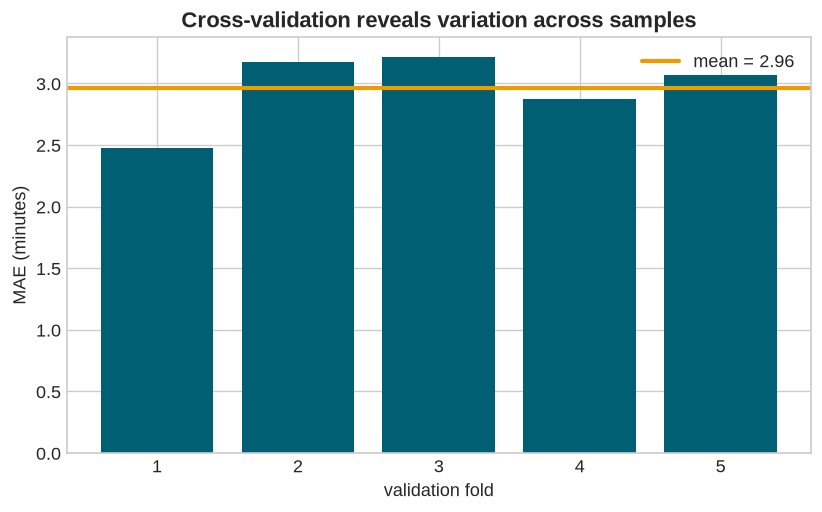

In [16]:
deliveries = delivery_records.copy()
X = deliveries[["distance_km", "items", "rain_mm"]]; y_delivery = deliveries["delivery_minutes"]
model = make_pipeline(StandardScaler(), Ridge(alpha=2)); cv = KFold(n_splits=5, shuffle=True, random_state=301)
cv_mae = -cross_val_score(model, X, y_delivery, scoring="neg_mean_absolute_error", cv=cv)
from sklearn.dummy import DummyRegressor
baseline_mae = -cross_val_score(DummyRegressor(strategy="mean"), X, y_delivery, scoring="neg_mean_absolute_error", cv=cv)
print(pd.Series({"5-fold mean-baseline MAE": baseline_mae.mean(), "5-fold MAE": cv_mae.mean(), "fold-to-fold SD": cv_mae.std()}).round(2))
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(range(1, 6), cv_mae, color=TEAL); ax.axhline(cv_mae.mean(), c=GOLD, lw=2.5, label=f"mean = {cv_mae.mean():.2f}")
ax.set(xlabel="validation fold", ylabel="MAE (minutes)", title="Cross-validation reveals variation across samples")
ax.legend(); plt.show()

<h2 id="9.-Classification-evaluation:-threshold,-ranking,-and-calibration">9. Classification evaluation: threshold, ranking, and calibration</h2>

threshold 0.25: review 35 of 78; Brier score 0.079
threshold 0.50: review 24 of 78; Brier score 0.079
threshold 0.75: review 13 of 78; Brier score 0.079


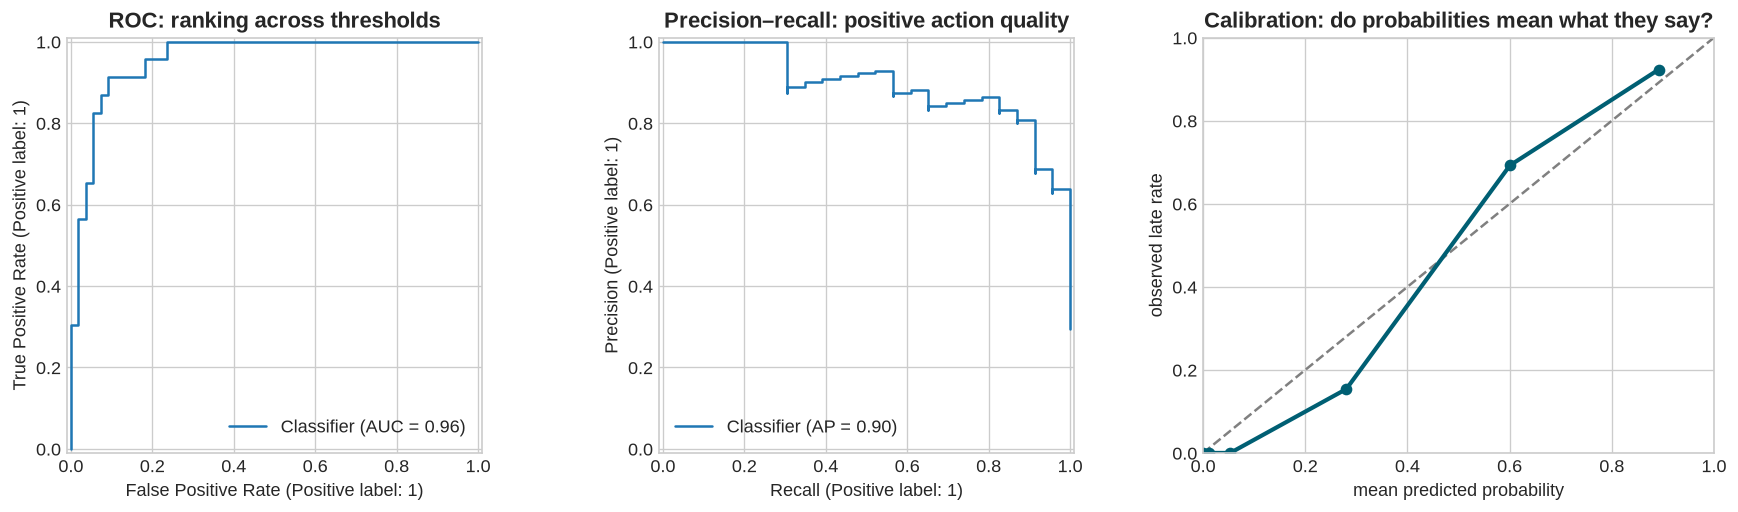

In [17]:
late = (deliveries.delivery_minutes > deliveries.delivery_minutes.quantile(.70)).astype(int)
X_tr, X_te, y_tr, y_te = train_test_split(X, late, stratify=late, test_size=.30, random_state=301)
classifier = make_pipeline(StandardScaler(), LogisticRegression()).fit(X_tr, y_tr)
score = classifier.predict_proba(X_te)[:, 1]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
RocCurveDisplay.from_predictions(y_te, score, ax=axes[0]); axes[0].set_title("ROC: ranking across thresholds")
PrecisionRecallDisplay.from_predictions(y_te, score, ax=axes[1]); axes[1].set_title("Precision–recall: positive action quality")
bins = pd.qcut(score, 6, duplicates="drop")
calibration = pd.DataFrame({"score": score, "outcome": y_te.to_numpy()}).groupby(bins, observed=True).mean()
axes[2].plot([0, 1], [0, 1], "--", c="grey"); axes[2].plot(calibration.score, calibration.outcome, "o-", c=TEAL, lw=2.5)
axes[2].set(xlim=(0,1), ylim=(0,1), xlabel="mean predicted probability", ylabel="observed late rate", title="Calibration: do probabilities mean what they say?")
plt.tight_layout()
for threshold in [.25, .50, .75]:
    action = score >= threshold
    print(f"threshold {threshold:.2f}: review {action.sum():2d} of {len(action)}; Brier score {brier_score_loss(y_te, score):.3f}")

<h2 id="Check-your-understanding">Check your understanding</h2><ol>
<li>Why can a low training loss coexist with poor decisions on future cases?</li>
<li>In the loss surface, what quantity changes at each gradient step?</li>
<li>Name a feature that would leak information in the delivery-time problem.</li>
<li>Which metric would change if a late delivery of 40 minutes mattered much more than one of 5 minutes?</li>
<li>Why does a probability require a threshold and capacity rule before it becomes an action?</li>
</ol>

<h2 id="Applied-learning-lab:-a-real-regression-problem">Applied learning lab: a real regression problem</h2><p>The diabetes study data is a compact real dataset for seeing the full learning contract. Each row is one participant, the columns are standardised baseline measurements, and the target is one-year disease progression. The fitted model is illustrative only.</p>

In [18]:
from sklearn.datasets import load_diabetes

diabetes = load_diabetes(as_frame=True).frame
diabetes[["bmi", "bp", "s5", "target"]].head(8)

,bmi,bp,s5,target
0,0.061696,0.021872,0.019907,151.0
1,-0.051474,-0.026328,-0.068332,75.0
2,0.044451,-0.005670,0.002861,141.0
3,-0.011595,-0.036656,0.022688,206.0
4,-0.036385,0.021872,-0.031988,135.0
5,-0.040696,-0.019442,-0.041176,97.0
6,-0.047163,-0.015999,-0.062917,138.0
7,-0.001895,0.066629,-0.035816,63.0


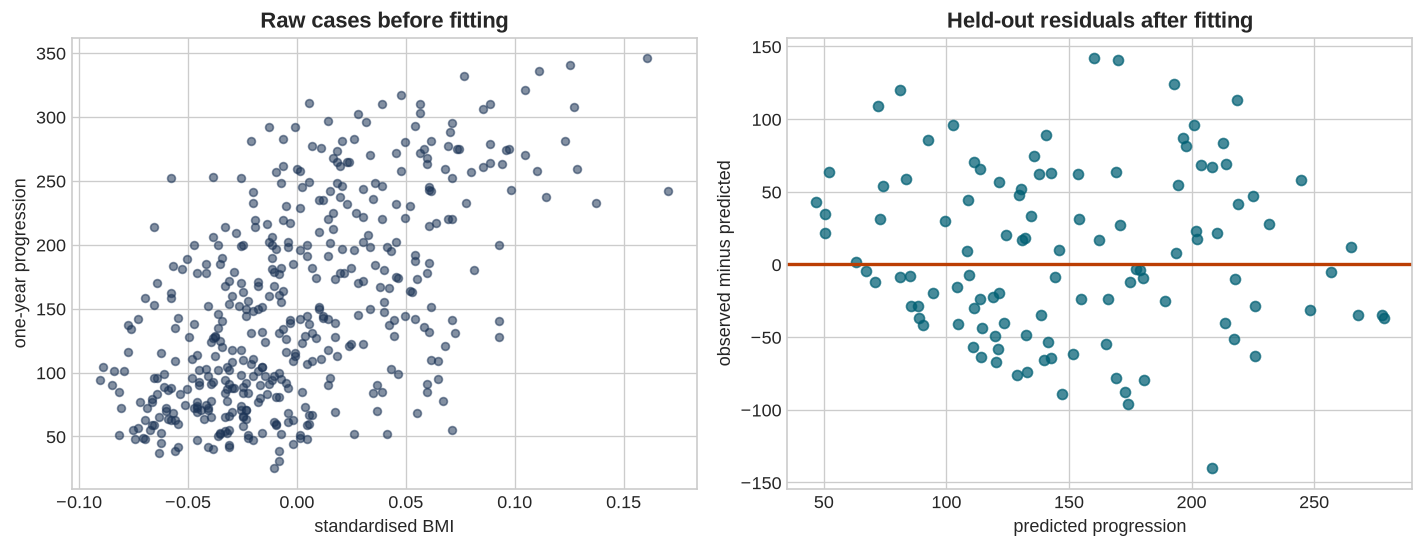

In [19]:
X_case = diabetes[["bmi", "bp", "s5"]]
y_case = diabetes.target
X_train, X_test, y_train, y_test = train_test_split(X_case, y_case, test_size=.25, random_state=301)
case_model = make_pipeline(StandardScaler(), Ridge(alpha=8)).fit(X_train, y_train)
prediction = case_model.predict(X_test)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.7))
axes[0].scatter(diabetes.bmi, diabetes.target, color=INK, alpha=.55, s=22)
axes[0].set(title="Raw cases before fitting", xlabel="standardised BMI", ylabel="one-year progression")
residual = y_test.to_numpy() - prediction
axes[1].scatter(prediction, residual, color=TEAL, alpha=.72)
axes[1].axhline(0, color=CORAL, lw=2)
axes[1].set(title="Held-out residuals after fitting", xlabel="predicted progression", ylabel="observed minus predicted")
plt.tight_layout()

<p>The residual plot asks a different question from the loss surface: after optimising a training objective, does the fitted rule leave a visible systematic error on data it did not see?</p>

## A loss landscape in three dimensions

We will predict the **flavanoids measurement of a wine from its total phenols**. These are observed chemical measurements from the Wine Recognition dataset. One row represents one wine sample. The original class label is deliberately excluded from this regression task.

First inspect the recorded measurements. We use only a training subset to build the landscape. Standardising its input and target makes the geometry readable; the displayed parameters and MSE are therefore in standardised units.

,total_phenols,flavanoids
0,2.80,3.06
1,2.65,2.76
2,2.80,3.24
3,3.85,3.49
4,2.80,2.69
5,3.27,3.39
6,2.50,2.52
7,2.60,2.51
8,2.80,2.98
9,2.98,3.15


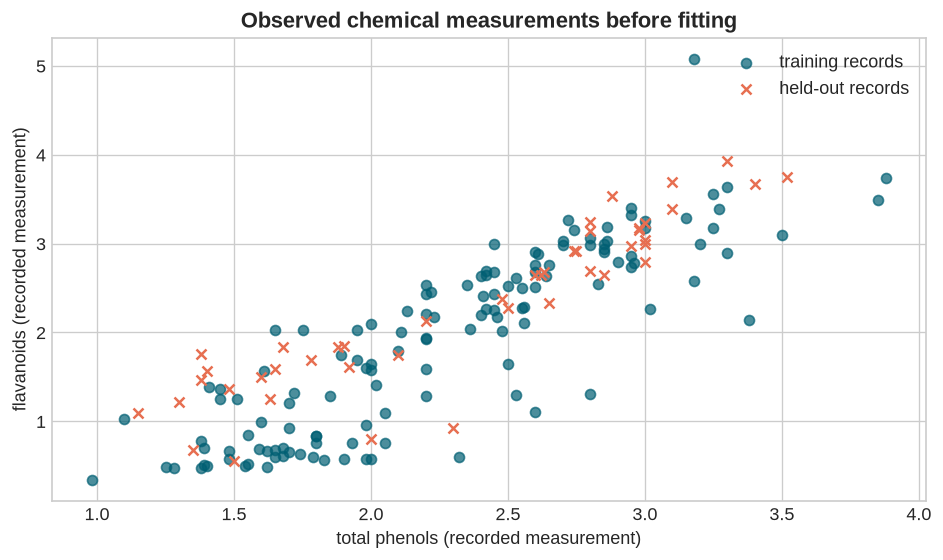

In [20]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from IPython.display import display
wine_loss = load_wine(as_frame=True).data[['total_phenols', 'flavanoids']]
display(wine_loss.head(10))
loss_train, loss_test = train_test_split(wine_loss, test_size=.25, random_state=301)
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.scatter(loss_train.total_phenols, loss_train.flavanoids, label='training records', color='#005F73', alpha=.7)
ax.scatter(loss_test.total_phenols, loss_test.flavanoids, label='held-out records', color='#E76F51', marker='x')
ax.set(xlabel='total phenols (recorded measurement)', ylabel='flavanoids (recorded measurement)', title='Observed chemical measurements before fitting')
ax.legend(); plt.tight_layout(); plt.show()

### Every height comes from prediction errors on these rows

Our candidate equation is $\hat z_y=b+wz_x$. For each parameter pair, predict every training outcome, subtract the recorded standardised target, square each residual, and average. That mean is the vertical height $J(b,w)$.

The table below makes this calculation visible for $b=-1.5,w=-1$. The surface repeats exactly this calculation over a grid of candidate equations. A point on the surface represents an entire fitted rule, not an individual wine.

,z input,z observed,z prediction,residual,squared residual
0,1.195,1.233,-2.695,-3.928,15.426
1,-1.639,-1.455,0.139,1.593,2.539
2,0.075,-1.325,-1.575,-0.249,0.062
3,1.113,1.462,-2.613,-4.074,16.599
4,-1.424,-0.539,-0.076,0.463,0.215
5,0.240,0.715,-1.740,-2.455,6.025
6,0.454,0.566,-1.954,-2.519,6.348
7,-1.358,-0.678,-0.142,0.537,0.288


Mean squared error across ALL training rows: 5.9661


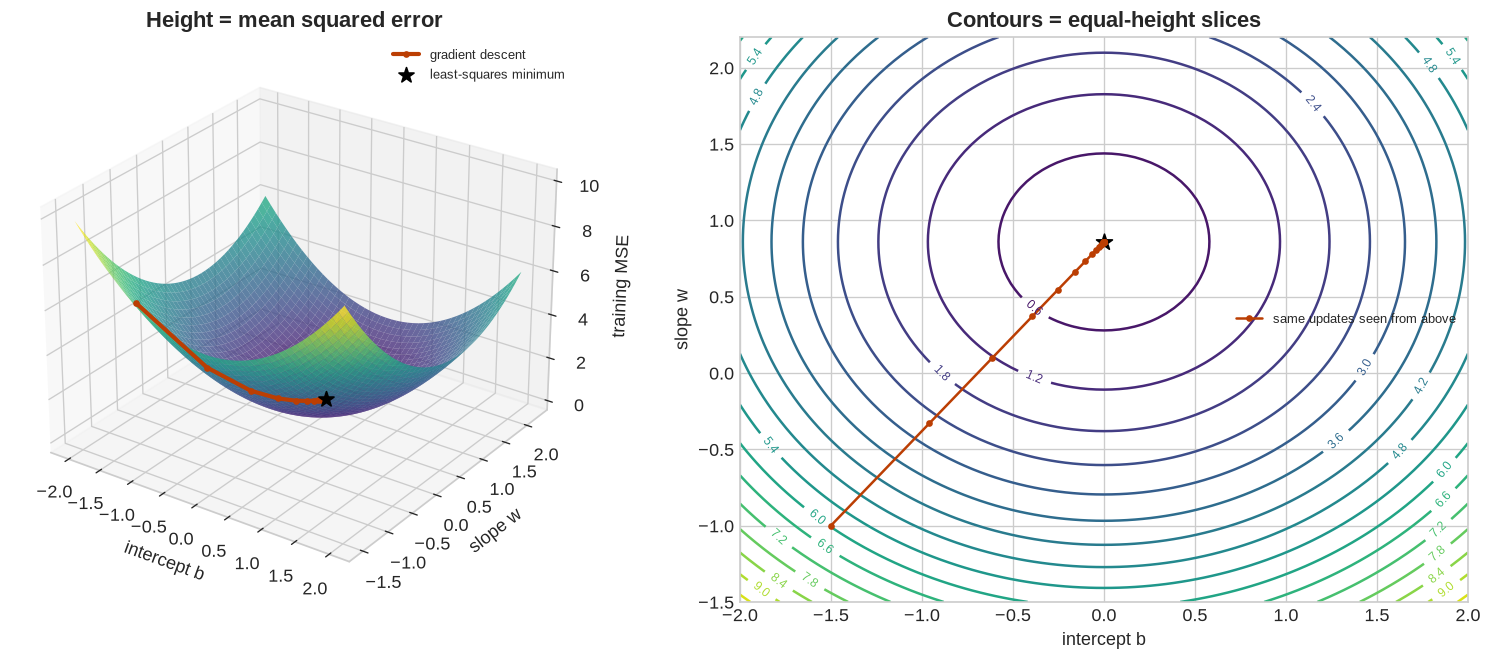

In [21]:
loss_scaler = StandardScaler().fit(loss_train)
loss_z = loss_scaler.transform(loss_train)
zx, zy = loss_z[:, 0], loss_z[:, 1]
design = np.column_stack([np.ones(len(zx)), zx])
theta_start = np.array([-1.5, -1.0])
initial_predictions = design @ theta_start
display(pd.DataFrame({'z input': zx, 'z observed': zy, 'z prediction': initial_predictions,
                      'residual': initial_predictions-zy, 'squared residual': (initial_predictions-zy)**2}).head(8).round(3))
print('Mean squared error across ALL training rows:', np.mean((initial_predictions-zy)**2).round(4))
intercepts = np.linspace(-2, 2, 95)
slopes = np.linspace(-1.5, 2.2, 95)
B, W = np.meshgrid(intercepts, slopes)
residual_grid = B[..., None] + W[..., None]*zx - zy
J = np.mean(residual_grid**2, axis=-1)
theta_opt = np.linalg.lstsq(design, zy, rcond=None)[0]
def mse_at(theta):
    return np.mean((design @ np.asarray(theta)-zy)**2)
def descend(rate=.18, steps=24):
    theta = theta_start.copy()
    history = [theta.copy()]
    for _ in range(steps):
        gradient = 2*design.T @ (design @ theta-zy)/len(zy)
        theta -= rate*gradient
        history.append(theta.copy())
    return np.asarray(history)
trajectory = descend()
heights = np.array([mse_at(t) for t in trajectory])
fig = plt.figure(figsize=(13, 5.4), layout='constrained')
ax3 = fig.add_subplot(121, projection='3d', computed_zorder=False)
surface = ax3.plot_surface(B, W, J, cmap='viridis', alpha=.78, linewidth=0, rasterized=True)
ax3.plot(trajectory[:,0], trajectory[:,1], heights, 'o-', color='#BB3E03', lw=2.5, markersize=3, label='gradient descent', zorder=10)
ax3.scatter(*theta_opt, mse_at(theta_opt), color='black', marker='*', s=90, label='least-squares minimum', zorder=11)
ax3.set(xlabel='intercept b', ylabel='slope w', zlabel='training MSE', title='Height = mean squared error')
ax3.view_init(elev=27, azim=-55); ax3.legend(fontsize=8)
ax2 = fig.add_subplot(122)
contour = ax2.contour(B, W, J, levels=15, cmap='viridis')
ax2.clabel(contour, fontsize=7)
ax2.plot(trajectory[:,0], trajectory[:,1], 'o-', color='#BB3E03', ms=3, label='same updates seen from above')
ax2.scatter(*theta_opt, marker='*', color='black', s=100)
ax2.set(xlabel='intercept b', ylabel='slope w', title='Contours = equal-height slices')
ax2.legend(fontsize=8); plt.show()

### The moving point changes the regression equation

Now return to the observations. Each coloured line below is one selected point from the descent path. The data stays fixed while the intercept and slope change. The curve on the right reports the same training MSE shown as height in the 3D view.

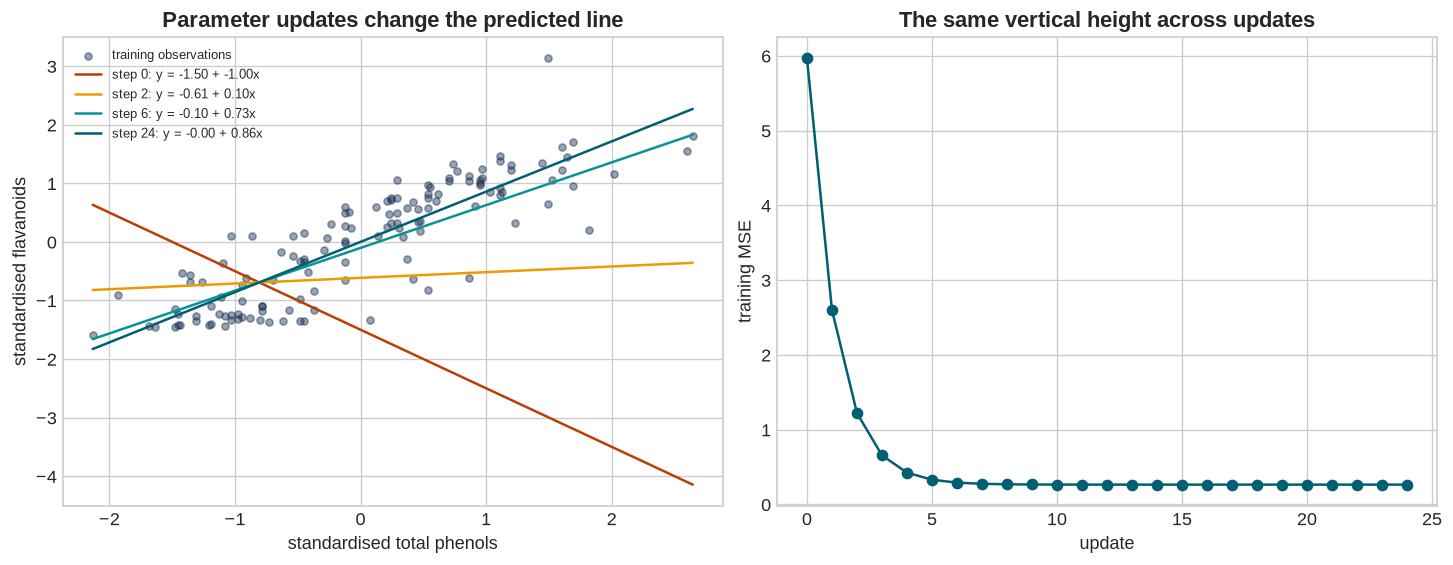

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), layout='constrained')
axes[0].scatter(zx, zy, c='#1D3557', s=18, alpha=.45, label='training observations')
line_x = np.linspace(zx.min(), zx.max(), 150)
for step, colour in zip([0, 2, 6, 24], ['#BB3E03', '#EE9B00', '#0A9396', '#005F73']):
    b, w = trajectory[step]
    axes[0].plot(line_x, b+w*line_x, color=colour, label=f'step {step}: y = {b:.2f} + {w:.2f}x')
axes[0].set(xlabel='standardised total phenols', ylabel='standardised flavanoids', title='Parameter updates change the predicted line')
axes[0].legend(fontsize=8)
axes[1].plot(np.arange(len(heights)), heights, 'o-', color='#005F73')
axes[1].set(xlabel='update', ylabel='training MSE', title='The same vertical height across updates')
plt.show()

### Changing the loss changes the landscape and fitted line

Use the same raw records and parameter grid. Absolute loss weights a residual in proportion to its magnitude. Squared loss grows faster. Huber loss is quadratic near zero and linear beyond $\delta=1$. Compare shapes **within** each plot: their vertical scales are different.

The minima marked here are numerical solutions of the three stated objectives. Their equations appear over the same training observations in the next plot.

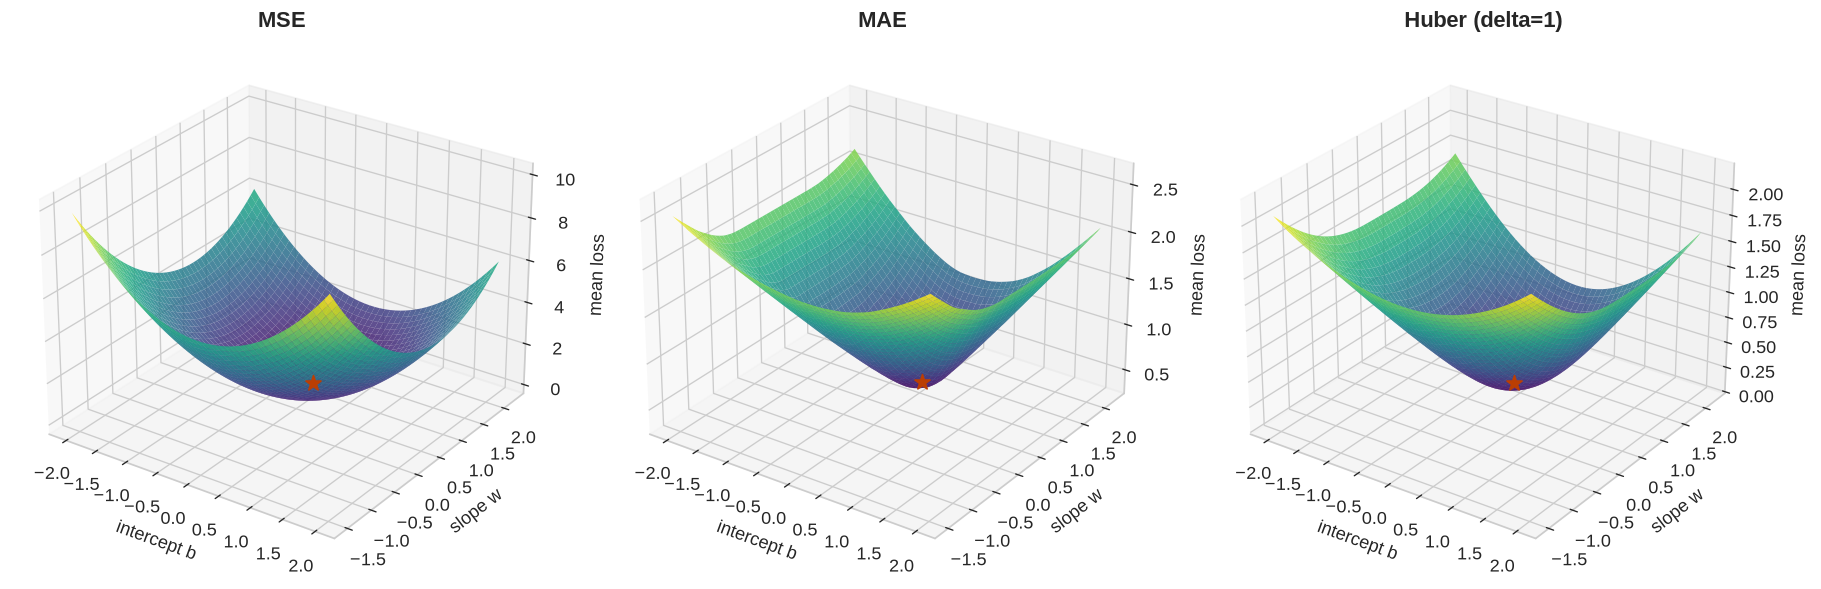

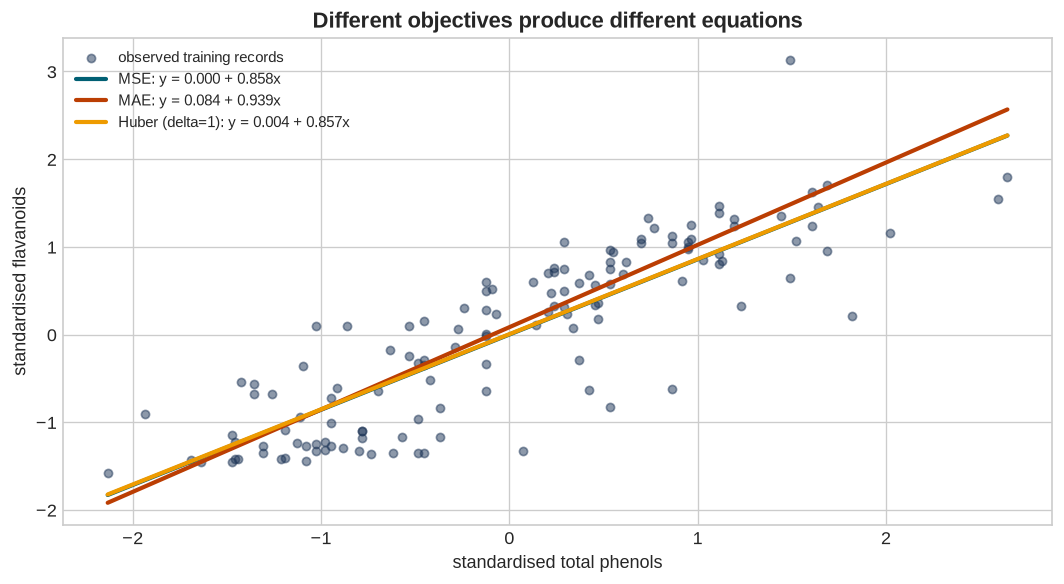

In [23]:
from scipy.optimize import minimize
from sklearn.linear_model import QuantileRegressor
absolute_grid = np.abs(residual_grid)
surfaces = {'MSE': J, 'MAE': absolute_grid.mean(axis=-1),
            'Huber (delta=1)': np.where(absolute_grid <= 1, .5*residual_grid**2, absolute_grid-.5).mean(axis=-1)}
def huber_value(theta):
    e = design @ theta - zy
    return np.where(np.abs(e)<=1, .5*e**2, np.abs(e)-.5).mean()
median_model = QuantileRegressor(quantile=.5, alpha=0, solver='highs').fit(zx[:,None], zy)
huber_fit = minimize(huber_value, theta_opt, method='BFGS', tol=1e-8)
solutions = {'MSE': theta_opt, 'MAE': np.array([median_model.intercept_, median_model.coef_[0]]), 'Huber (delta=1)': huber_fit.x}
fig = plt.figure(figsize=(15, 4.8), layout='constrained')
for i, (name, heights_grid) in enumerate(surfaces.items(), 1):
    ax = fig.add_subplot(1, 3, i, projection='3d', computed_zorder=False)
    ax.plot_surface(B, W, heights_grid, cmap='viridis', alpha=.85, linewidth=0, rasterized=True)
    sol = solutions[name]
    val = {'MSE': mse_at, 'MAE': lambda t: np.abs(design@t-zy).mean(), 'Huber (delta=1)': huber_value}[name](sol)
    ax.scatter(*sol, val, marker='*', c='#BB3E03', s=90, zorder=11)
    ax.set(xlabel='intercept b', ylabel='slope w', zlabel='mean loss', title=name)
    ax.view_init(27, -55)
plt.show()
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(zx, zy, color='#1D3557', alpha=.5, s=24, label='observed training records')
for (name, sol), colour in zip(solutions.items(), ['#005F73', '#BB3E03', '#EE9B00']):
    ax.plot(line_x, sol[0]+sol[1]*line_x, lw=2.5, color=colour, label=f'{name}: y = {sol[0]:.3f} + {sol[1]:.3f}x')
ax.set(xlabel='standardised total phenols', ylabel='standardised flavanoids', title='Different objectives produce different equations')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

### Learning rate and curvature explain the path

For this standardised linear model, the Hessian is $H=2X^TX/n$. Gradient descent converges for $0<\eta<2/\lambda_{\max}(H)$. This bound belongs to this quadratic objective; it is not a universal learning-rate rule.

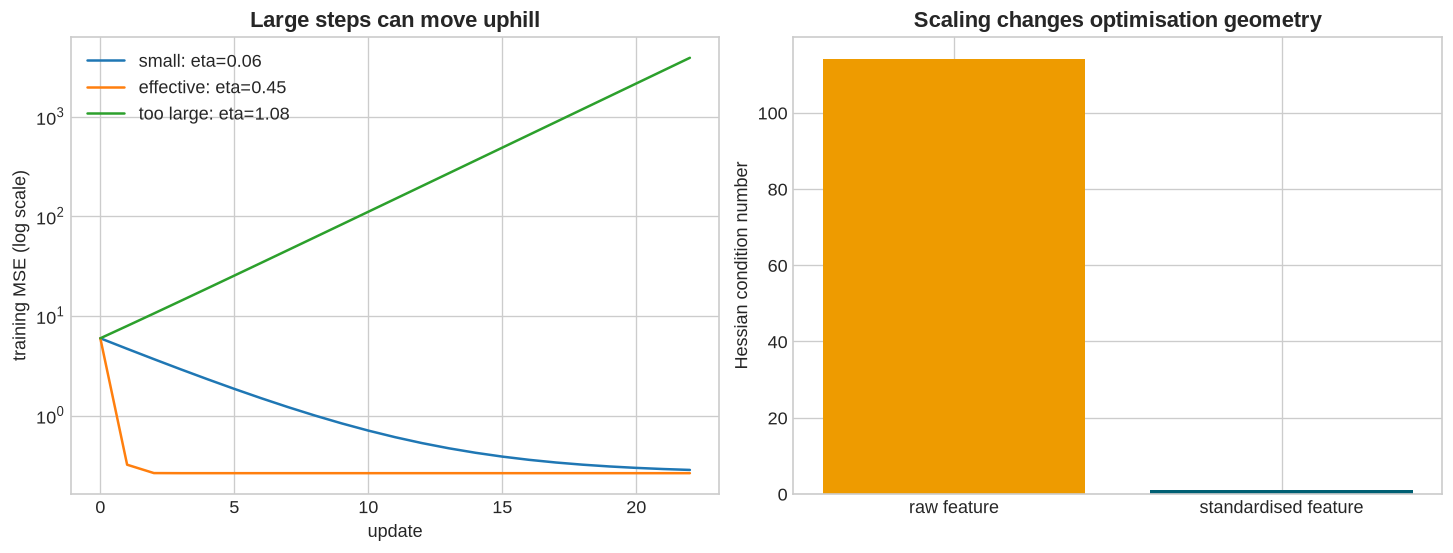

,model,held-out MSE
0,training-mean baseline,0.9696
1,fitted least squares,0.2230


In [24]:
H = 2*design.T@design/len(zy)
rate_bound = 2/np.linalg.eigvalsh(H).max()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout='constrained')
for rate, name in [(rate_bound*.06, 'small'), (rate_bound*.45, 'effective'), (rate_bound*1.08, 'too large')]:
    path_rate = descend(rate, steps=22)
    axes[0].semilogy([mse_at(t) for t in path_rate], label=f'{name}: eta={rate:.2f}')
axes[0].set(xlabel='update', ylabel='training MSE (log scale)', title='Large steps can move uphill'); axes[0].legend()
raw_design = np.column_stack([np.ones(len(loss_train)), loss_train.total_phenols])
raw_H = 2*raw_design.T@raw_design/len(loss_train)
axes[1].bar(['raw feature', 'standardised feature'], [np.linalg.cond(raw_H), np.linalg.cond(H)], color=['#EE9B00','#005F73'])
axes[1].set(ylabel='Hessian condition number', title='Scaling changes optimisation geometry')
plt.show()
test_z = loss_scaler.transform(loss_test)
test_prediction = theta_opt[0] + theta_opt[1]*test_z[:,0]
baseline_prediction = np.zeros(len(test_z))
display(pd.DataFrame({'model':['training-mean baseline','fitted least squares'],
                      'held-out MSE':[np.mean((test_z[:,1]-baseline_prediction)**2), np.mean((test_z[:,1]-test_prediction)**2)]}).round(4))

The minimum of the training surface answers an optimisation question. The held-out comparison answers a generalisation question. Neither is a causal estimate. **Class exercise:** predict what changes in the 3D landscape, line plot, and held-out error if the largest observed residual is doubled. Then test your prediction using a copy of the training data.

## Learning curves: does more evidence help?

Return to the real wine samples from the loss demonstration. We now use all chemical features to classify the recorded cultivar. Inspect the rows below before splitting. A learning curve refits the same model on progressively larger training subsets. Its validation folds measure how additional examples affect prediction, with the test subset still reserved.

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
5,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0,0
6,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0,0
7,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0,0


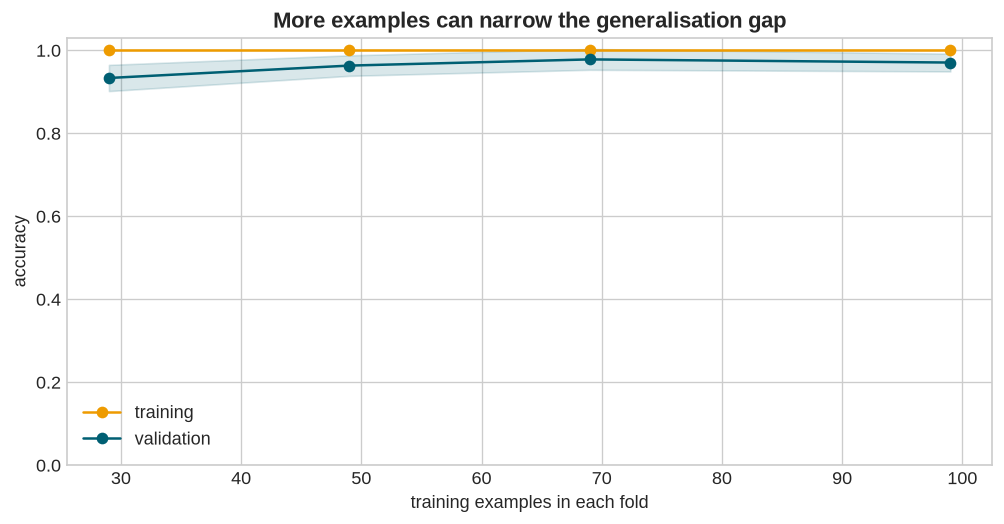

In [25]:
from sklearn.datasets import load_wine
from sklearn.model_selection import learning_curve, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import ConfusionMatrixDisplay
case_wine=load_wine(as_frame=True)
display(case_wine.frame.head(8))
lc_X, final_X, lc_y, final_y=train_test_split(case_wine.data,case_wine.target,stratify=case_wine.target,test_size=.25,random_state=301)
lc_model=make_pipeline(StandardScaler(),LogisticRegression(max_iter=2000))
folds=StratifiedKFold(4,shuffle=True,random_state=301)
sizes,tr_scores,va_scores=learning_curve(lc_model,lc_X,lc_y,cv=folds,train_sizes=[.3,.5,.7,1.],scoring='accuracy',shuffle=True,random_state=301)
fig,ax=plt.subplots(figsize=(8.5,4.5))
for values,label,colour in [(tr_scores,'training','#EE9B00'),(va_scores,'validation','#005F73')]:
    ax.plot(sizes,values.mean(axis=1),'o-',label=label,color=colour)
    ax.fill_between(sizes,values.mean(axis=1)-values.std(axis=1),values.mean(axis=1)+values.std(axis=1),alpha=.15,color=colour)
ax.set(xlabel='training examples in each fold',ylabel='accuracy',ylim=(0,1.03),title='More examples can narrow the generalisation gap'); ax.legend(); plt.tight_layout(); plt.show()

## Nested validation evaluates the selection procedure

Choosing a hyperparameter and reporting its best validation score reuses evidence. Here an inner loop chooses $C$ and an outer loop assesses that choice on different records. The outer scores describe the whole selection procedure. The final test set remains outside both loops.

,outer fold,accuracy
0,1,0.970588
1,2,0.969697
2,3,1.000000
3,4,0.939394


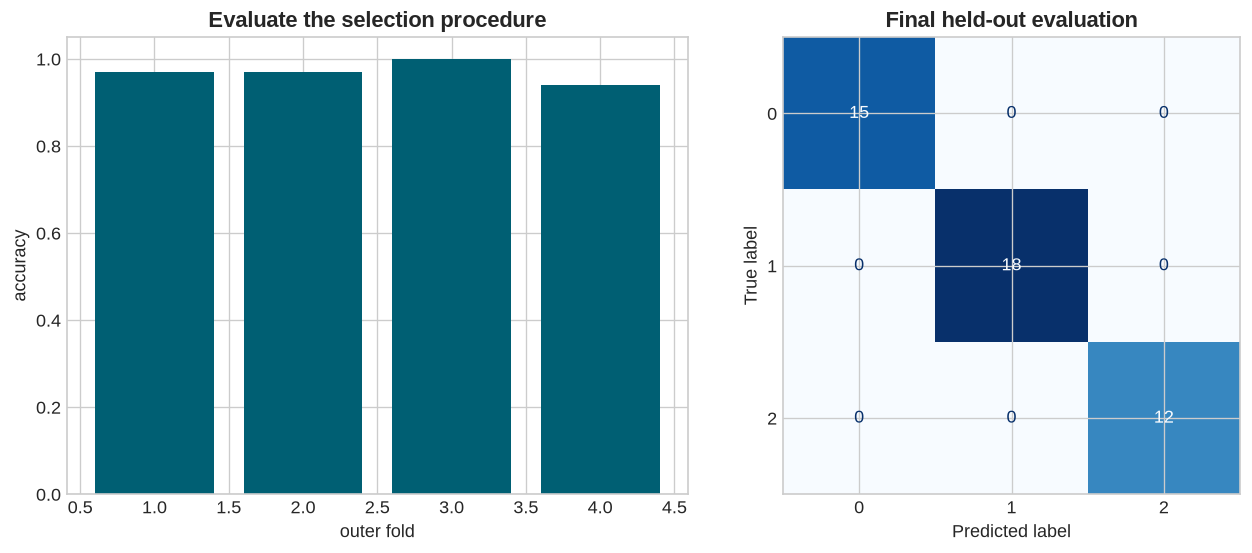

In [26]:
inner=StratifiedKFold(3,shuffle=True,random_state=17)
selection=GridSearchCV(lc_model,{'logisticregression__C':[.01,.1,1,10]},cv=inner,scoring='accuracy')
outer_scores=cross_val_score(selection,lc_X,lc_y,cv=folds,scoring='accuracy')
display(pd.DataFrame({'outer fold':np.arange(1,5),'accuracy':outer_scores}))
selection.fit(lc_X,lc_y)
fig,axes=plt.subplots(1,2,figsize=(11,4.5),layout='constrained')
axes[0].bar(np.arange(1,5),outer_scores,color='#005F73'); axes[0].set(xlabel='outer fold',ylabel='accuracy',ylim=(0,1.05),title='Evaluate the selection procedure')
ConfusionMatrixDisplay.from_predictions(final_y,selection.predict(final_X),ax=axes[1],colorbar=False,cmap='Blues')
axes[1].set_title('Final held-out evaluation'); plt.show()

## Bias, variance and irreducible noise

This controlled simulation supplements the observed datasets because repeated alternative training samples and the true mean function are known here. We generate noisy observations from $f(x)=\sin(2x)$, display one raw sample, and refit models to repeated samples. The decomposition is pointwise squared prediction error: bias squared plus model variance plus outcome noise variance. Its meaning depends on the data-generating process and training procedure.

,x,observed y
0,-0.297778,-0.540658
1,-0.899142,-1.593249
2,-0.457118,-0.445993
3,1.280620,0.503080
4,1.153156,0.674364
5,0.699413,1.140861
6,-1.204634,-0.337866
7,-1.376104,-0.443032


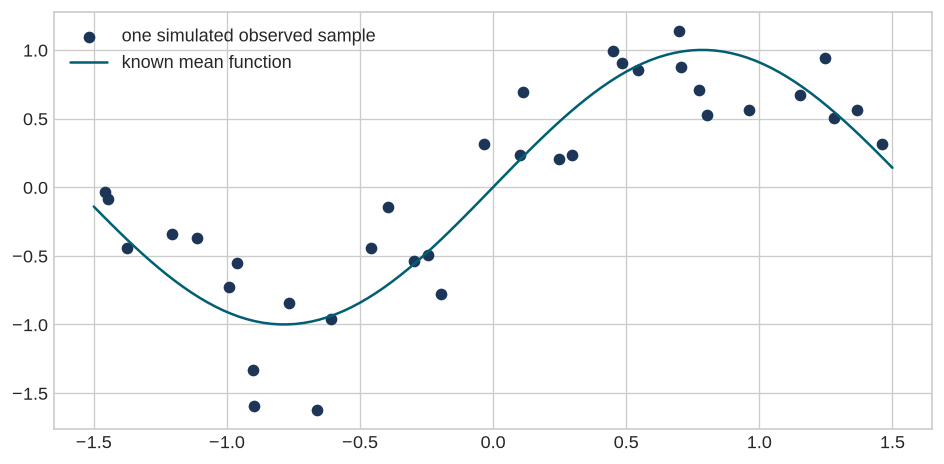

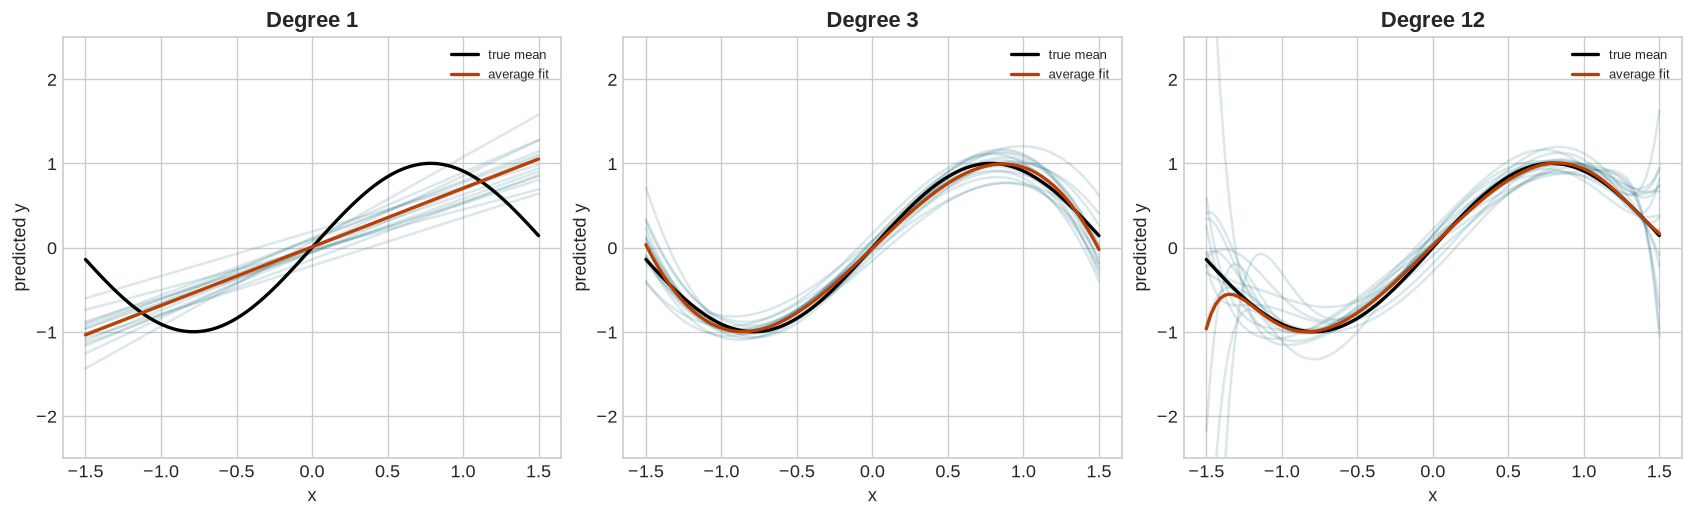

,bias squared,variance,noise variance
degree,,,
1,0.1716,0.0188,0.1225
3,0.0034,0.0184,0.1225
12,0.0146,0.2292,0.1225


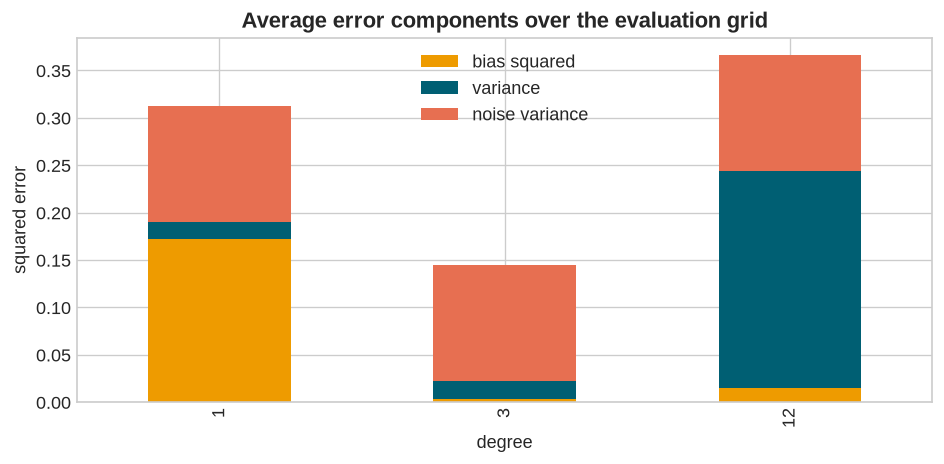

In [27]:
bv_rng=np.random.default_rng(301)
bv_grid=np.linspace(-1.5,1.5,100)
truth=np.sin(2*bv_grid)
noise_sd=.35
sample_x=bv_rng.uniform(-1.5,1.5,35)
sample_y=np.sin(2*sample_x)+bv_rng.normal(0,noise_sd,35)
display(pd.DataFrame({'x':sample_x,'observed y':sample_y}).head(8))
fig,ax=plt.subplots(figsize=(8,4))
ax.scatter(sample_x,sample_y,color='#1D3557',label='one simulated observed sample')
ax.plot(bv_grid,truth,color='#005F73',label='known mean function'); ax.legend(); plt.tight_layout(); plt.show()
bv_rows=[]
fig,axes=plt.subplots(1,3,figsize=(14,4.2),layout='constrained')
for ax,degree in zip(axes,[1,3,12]):
    predictions=[]
    for repeat in range(60):
        xx=bv_rng.uniform(-1.5,1.5,35)
        yy=np.sin(2*xx)+bv_rng.normal(0,noise_sd,35)
        model=make_pipeline(PolynomialFeatures(degree,include_bias=False),StandardScaler(),Ridge(alpha=.05,solver='svd')).fit(xx[:,None],yy)
        predictions.append(model.predict(bv_grid[:,None]))
    predictions=np.array(predictions)
    ax.plot(bv_grid,predictions[:15].T,color='#005F73',alpha=.14)
    ax.plot(bv_grid,truth,color='black',lw=2,label='true mean')
    ax.plot(bv_grid,predictions.mean(axis=0),color='#BB3E03',lw=2,label='average fit')
    ax.set(title=f'Degree {degree}',xlabel='x',ylabel='predicted y',ylim=(-2.5,2.5)); ax.legend(fontsize=8)
    bv_rows.append([degree,np.mean((predictions.mean(axis=0)-truth)**2),np.mean(predictions.var(axis=0)),noise_sd**2])
plt.show()
bv_table=pd.DataFrame(bv_rows,columns=['degree','bias squared','variance','noise variance']).set_index('degree')
display(bv_table.round(4))
bv_table.plot.bar(stacked=True,figsize=(8,4),color=['#EE9B00','#005F73','#E76F51'],title='Average error components over the evaluation grid')
plt.ylabel('squared error'); plt.tight_layout(); plt.show()

## Momentum, mini-batches, epochs and updates

Use the wine regression rows already displayed above. A batch gradient uses all training rows, a stochastic gradient uses one, and a mini-batch gradient uses a subset. One epoch visits the training rows once. The plot uses updates on its horizontal axis, so methods do different amounts of work per plotted point. Momentum accumulates a decaying history of gradients: $v_t=\beta v_{t-1}+g_t$, followed by $\theta_{t+1}=\theta_t-\eta v_t$.

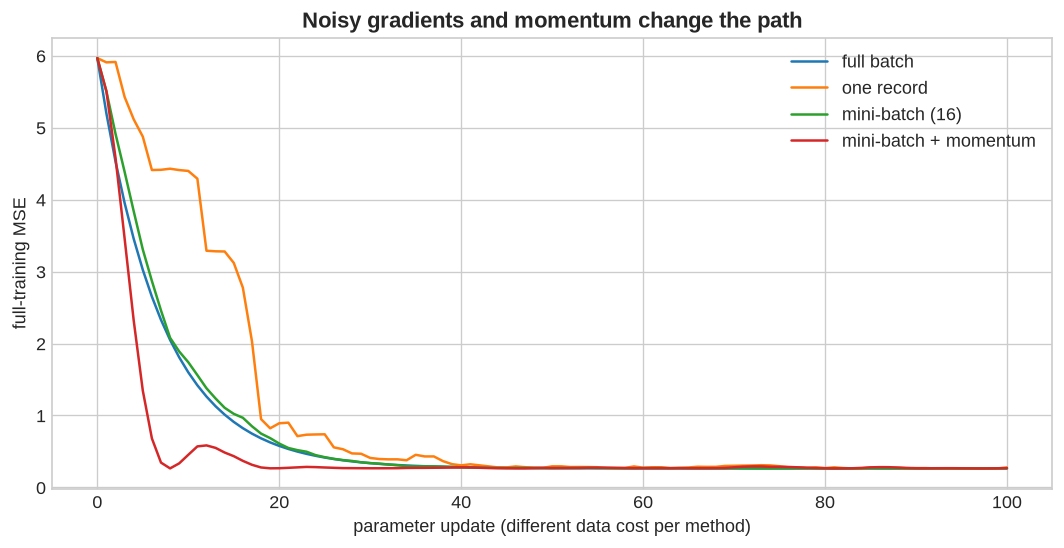

In [28]:
fig,ax=plt.subplots(figsize=(9,4.7))
for batch_size,beta,label in [(len(zx),0.,'full batch'),(1,0.,'one record'),(16,0.,'mini-batch (16)'),(16,.8,'mini-batch + momentum')]:
    local_rng=np.random.default_rng(17)
    theta=theta_start.copy(); velocity=np.zeros(2); tracked=[mse_at(theta)]
    for update in range(100):
        ix=local_rng.choice(len(zx),size=batch_size,replace=False)
        gradient=2*design[ix].T@(design[ix]@theta-zy[ix])/batch_size
        velocity=beta*velocity+gradient
        theta-=.035*velocity
        tracked.append(mse_at(theta))
    ax.plot(tracked,label=label)
ax.set(xlabel='parameter update (different data cost per method)',ylabel='full-training MSE',title='Noisy gradients and momentum change the path'); ax.legend(); plt.tight_layout(); plt.show()

## Distribution shift: which relationship changed?

The following explicitly simulated records let us isolate three changes. Covariate shift changes $P(X)$ while preserving $P(Y\mid X)$. Label shift changes $P(Y)$ while preserving $P(X\mid Y)$. Concept shift changes $P(Y\mid X)$. A changed histogram is a monitoring signal; identifying the type of shift needs assumptions and often newly verified labels.

,original x,original label
0,0.400549,0
1,-1.614439,0
2,-1.836931,0
3,-1.027566,0
4,-0.074720,1
5,-1.768740,0
6,0.520492,0
7,-0.478366,0


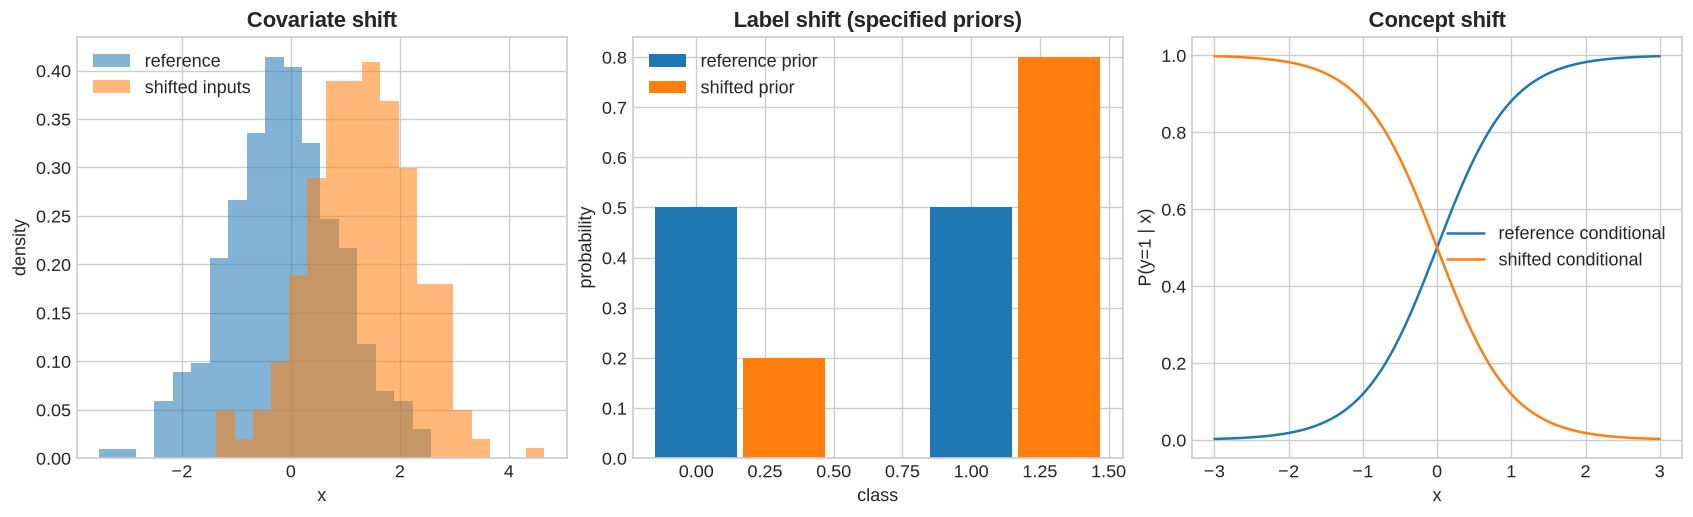

In [29]:
shift_rng=np.random.default_rng(301)
sx=shift_rng.normal(size=300); sy=(sx+shift_rng.normal(size=300)>.2).astype(int)
display(pd.DataFrame({'original x':sx,'original label':sy}).head(8))
fig,axes=plt.subplots(1,3,figsize=(14,4.2),layout='constrained')
new_x=shift_rng.normal(1.2,1,300)
axes[0].hist(sx,bins=18,alpha=.55,density=True,label='reference')
axes[0].hist(new_x,bins=18,alpha=.55,density=True,label='shifted inputs')
axes[0].set(title='Covariate shift',xlabel='x',ylabel='density'); axes[0].legend()
axes[1].bar([0,1],[.5,.5],width=.3,label='reference prior')
axes[1].bar(np.array([0,1])+.32,[.2,.8],width=.3,label='shifted prior')
axes[1].set(title='Label shift (specified priors)',xlabel='class',ylabel='probability'); axes[1].legend()
xx=np.linspace(-3,3,150)
axes[2].plot(xx,1/(1+np.exp(-2*xx)),label='reference conditional')
axes[2].plot(xx,1/(1+np.exp(2*xx)),label='shifted conditional')
axes[2].set(title='Concept shift',xlabel='x',ylabel='P(y=1 | x)'); axes[2].legend(); plt.show()